# import Libraries

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Fetch or Load Dataset

In [67]:
data = pd.read_csv("../data/raw/Amazon Sale Report.csv")

C:\Users\altam\AppData\Local\Temp\ipykernel_23448\3426902795.py:1: DtypeWarning: Columns (0: Unnamed: 22) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("../data/raw/Amazon Sale Report.csv")


# See all Columns

In [68]:
pd.set_option('display.max_columns', None)

# Understanding Dataset

In [69]:
data.head()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,ASIN,Courier Status,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,S,B09KXVBD7Z,NaN,0,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,B09K3WFS32,Shipped,1,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,XL,B07WV4JV4D,Shipped,1,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,L,B099NRCT7B,NaN,0,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,3XL,B098714BZP,Shipped,1,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


In [70]:
#check dataset shape
data.shape

(128975, 24)

In [71]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order ID            128975 non-null  str    
 2   Date                128975 non-null  str    
 3   Status              128975 non-null  str    
 4   Fulfilment          128975 non-null  str    
 5   Sales Channel       128975 non-null  str    
 6   ship-service-level  128975 non-null  str    
 7   Style               128975 non-null  str    
 8   SKU                 128975 non-null  str    
 9   Category            128975 non-null  str    
 10  Size                128975 non-null  str    
 11  ASIN                128975 non-null  str    
 12  Courier Status      122103 non-null  str    
 13  Qty                 128975 non-null  int64  
 14  currency            121180 non-null  str    
 15  Amount              121180 non-null  float64


# Data Cleaning

In [72]:
# Multiple columns drop
data.drop(columns=['Unnamed: 22', 'fulfilled-by', 'ship-country', 'currency', 'Order ID', 'index'], inplace=True)

In [73]:
# single Column Drop
data.drop('B2B', axis = 1, inplace = True)

In [74]:
# drop NAN vlaues
data.dropna(subset='ship-state', inplace=True)

In [75]:
data.shape

(128942, 17)

# Feature Engineering

In [76]:
# change string data type to datetime data type of 'Date' column
date = pd.to_datetime(data['Date'], format='%m-%d-%y')
data['Date'] = date

In [77]:
data.info()

<class 'pandas.DataFrame'>
Index: 128942 entries, 0 to 128974
Data columns (total 17 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   Date                128942 non-null  datetime64[us]
 1   Status              128942 non-null  str           
 2   Fulfilment          128942 non-null  str           
 3   Sales Channel       128942 non-null  str           
 4   ship-service-level  128942 non-null  str           
 5   Style               128942 non-null  str           
 6   SKU                 128942 non-null  str           
 7   Category            128942 non-null  str           
 8   Size                128942 non-null  str           
 9   ASIN                128942 non-null  str           
 10  Courier Status      122073 non-null  str           
 11  Qty                 128942 non-null  int64         
 12  Amount              121149 non-null  float64       
 13  ship-city           128942 non-null  str     

In [78]:
# check shape
data.shape

(128942, 17)

In [79]:
# making new Columns name with months and years
data['months_num'] = data['Date'].dt.month
data['months_name'] = data['Date'].dt.month_name()
data['years'] = data['Date'].dt.year

# check shape
data.shape

(128942, 20)

In [80]:
# convert data of columns to uppercase and remove leading/trailing whitespace
data['ship-state'] = data['ship-state'].str.upper().str.strip()

In [81]:
# create Dictionary for mapping state names
state_map = {'NEW DELHI': 'DELHI', 'PUNJAB/MOHALI/ZIRAKPUR':'PUNJAB', 'PB':'PUNJAB', 'APO':'ANDHRA PRADESH', 'NL': 'NAGALAND', 'AR': 'ARUNACHAL PRADESH', 'RAJSTHAN':'RAJASTHAN', 'RAJSHTHAN':'RAJASTHAN', 'RJ':'RAJASTHAN', 'ORISSA':'ODISHA', 'PONDICHERRY':'PUDUCHERRY'}

In [82]:
# mapping sates names
data['ship-state'] = data['ship-state'].replace(state_map)

In [83]:
# make upper case and remove trailing/leading whitespace
data['Status'] = data['Status'].str.upper().str.strip()

In [84]:
# create dictionary for mapping status values
status_map = {"SHIPPED - PICKED UP": "SHIPPED/IN TRANSIT","SHIPPED":"SHIPPED/IN TRANSIT", "SHIPPED - OUT FOR DELIVERY":"SHIPPED/IN TRANSIT", "SHIPPED - DELIVERED TO BUYER":"DELIVERED", "CANCELLED":"RETURNED/CANCELLED", "SHIPPED - RETURNING TO SELLER": "RETURNED/CANCELLED", "SHIPPED - RETURNED TO SELLER":"RETURNED/CANCELLED", "SHIPPED - REJECTED BY BUYER":"RETURNED/CANCELLED", "SHIPPED - DAMAGED":"RETURNED/CANCELLED", "PENDING - WAITING FOR PICK UP":"PENDING", "SHIPPED - LOST IN TRANSIT":"LOST", 'SHIPPING':'SHIPPED/IN TRANSIT'}

In [85]:
# Mapping status values
data['Status'] = data['Status'].replace(status_map)

# Visualisation and EDA

<Axes: title={'center': 'Sales Amount by Months'}, xlabel='Months', ylabel='Sales Amount'>

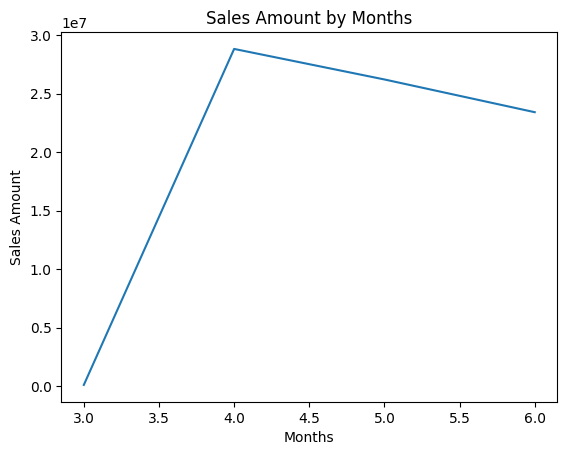

In [89]:
# Bar Graph

data.groupby('months_num')['Amount'].sum().plot(kind='line',
                                            title = 'Sales Amount by Months',
                                            xlabel = 'Months',
                                            ylabel = 'Sales Amount')

# data.groupby('months')['Amount'].sum().plot(kind='line')
# plt.title('Total sales Amount by Months')
# plt.xlabel('Months')
# plt.ylabel('Sales Amount')

# plt.show()

In [86]:
data.groupby('months_num')['Amount'].sum()

months_num
3      101683.85
4    28831249.32
5    26219850.75
6    23421223.38
Name: Amount, dtype: float64

<Axes: title={'center': 'Sales Amount by Category'}, xlabel='Category', ylabel='Sales Amount'>

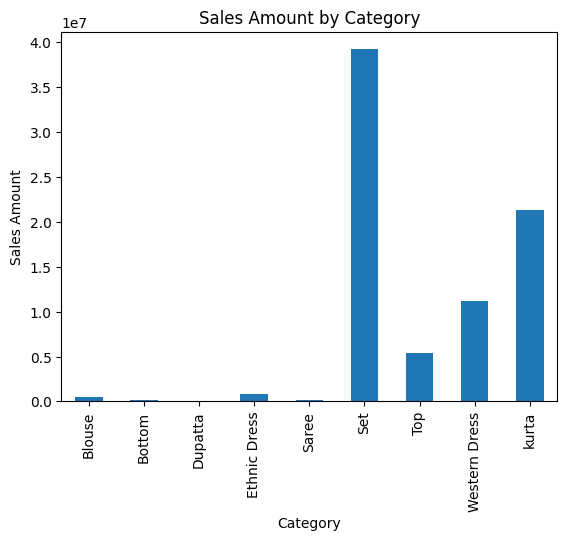

In [56]:
# top to low
data.groupby('Category')['Amount'].sum().plot(kind='bar',
                                              title='Sales Amount by Category',
                                              xlabel='Category',
                                              ylabel='Sales Amount')

# data.groupby('Category')['Amount'].sum().plot(kind='bar')

# plt.title('Sales Amount by Category')
# plt.xlabel('Category')
# plt.ylabel('Sales Amount')

# plt.show()

In [57]:
# top to low
data.groupby('Category')['Amount'].sum().sort_values(ascending=False)

Category
Set              39195176.03
kurta            21291538.70
Western Dress    11215337.69
Top               5346812.30
Ethnic Dress       791217.66
Blouse             458408.18
Bottom             150667.98
Saree              123933.76
Dupatta               915.00
Name: Amount, dtype: float64

<Axes: title={'center': 'Top 10 States by Sales Amount'}, xlabel='States', ylabel='Sales Amount'>

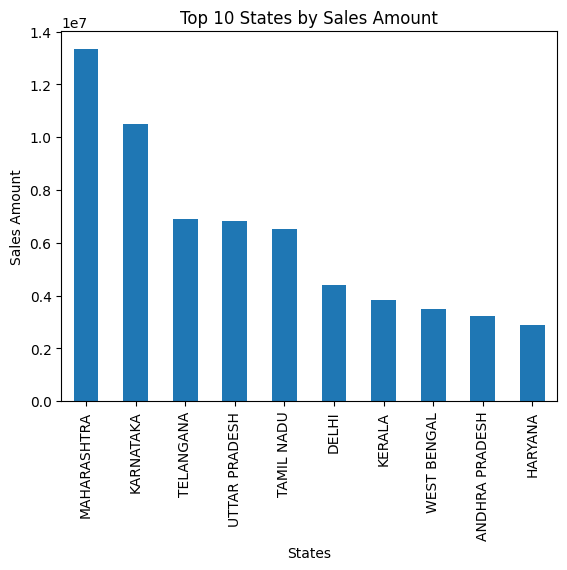

In [58]:
data.groupby('ship-state')['Amount'].sum().sort_values(ascending=False).head(10).plot(kind='bar',
                                                                                      title='Top 10 States by Sales Amount',
                                                                                      xlabel='States',
                                                                                      ylabel='Sales Amount')

In [59]:
data.groupby('ship-state')['Amount'].sum().sort_values(ascending=False).head(10)

ship-state
MAHARASHTRA       13335534.14
KARNATAKA         10481114.37
TELANGANA          6916615.65
UTTAR PRADESH      6816642.08
TAMIL NADU         6515650.11
DELHI              4393522.41
KERALA             3830227.58
WEST BENGAL        3507880.44
ANDHRA PRADESH     3219831.72
HARYANA            2882092.99
Name: Amount, dtype: float64

<Axes: title={'center': 'Top 10 Styles by Sales Amount'}, xlabel='Styles', ylabel='Sales Amount'>

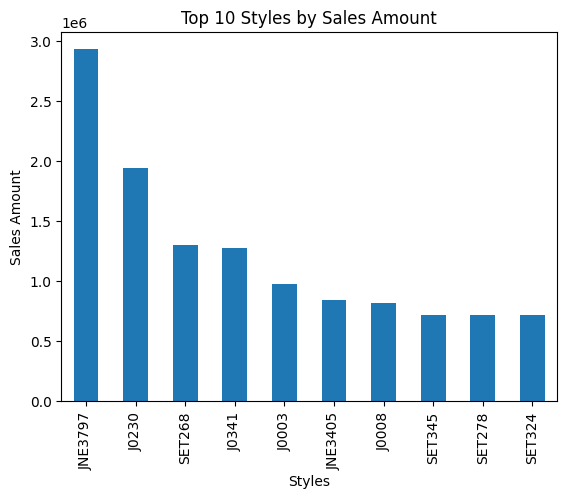

In [60]:
data.groupby('Style')['Amount'].sum().sort_values(ascending=False).head(10).plot(kind='bar',
                                                                                 title='Top 10 Styles by Sales Amount',
                                                                                 xlabel='Styles',
                                                                                 ylabel='Sales Amount')

In [61]:
data.groupby('Style')['Amount'].sum().sort_values(ascending=False).head(10)

Style
JNE3797    2932747.00
J0230      1943836.48
SET268     1303923.56
J0341      1275322.87
J0003       980665.75
JNE3405     846062.36
J0008       819169.96
SET345      723402.79
SET278      719791.48
SET324      719489.82
Name: Amount, dtype: float64

<Axes: title={'center': 'Total Sales Amount by Status'}, xlabel='Status', ylabel='Sales Amount'>

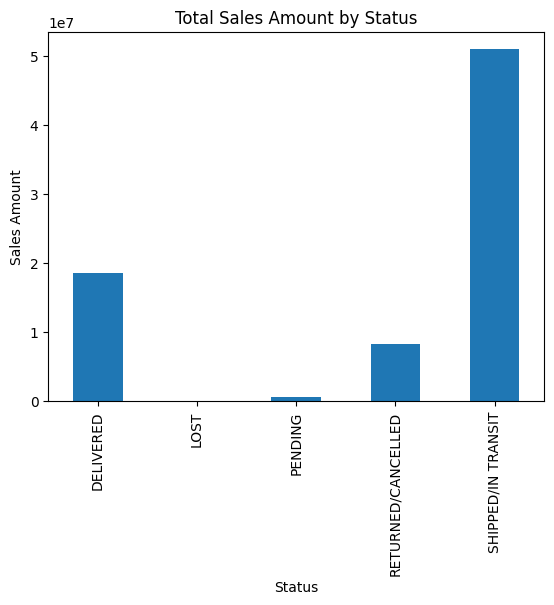

In [62]:
data.groupby('Status')['Amount'].sum().plot(kind='bar',
                                            title='Total Sales Amount by Status',
                                            xlabel='Status',
                                            ylabel='Sales Amount')

In [63]:
data.groupby('Status')['Amount'].sum()

Status
DELIVERED             18645779.0
LOST                      1997.0
PENDING                 622409.0
RETURNED/CANCELLED     8301320.3
SHIPPED/IN TRANSIT    51002502.0
Name: Amount, dtype: float64

# Save New CSV file 

In [64]:
data.to_csv('../data/cleaned/cleaned_amazon_sales_report.csv', index=False)

# Key Insights

### - Maharashtra generated the highest sales revenue among all the states.
### - The 'Set' category contributed the highest overall Sales.
### - Style JNE3797 was the top - performing product style.
### - April recorded the highest monthly sales in the dataset.
### - A significant portion of revenue was associated with returned/cancelled orders.
### - Most order were in the ship/in-transit stage.

# Conclusion

### This Project involved cleaning, transforming, and analyzing e-commerce sales data to identify important business trends and operational patterns. The analysis helped uncover high performing product categories, top-selling states, monthly sales trends, and order status distribution. This project also demonstrated the data cleaning, feature engineering, exploratory data analysis(EDA), and visualisation skills using python libraries.